# LiDAR Ground Slope & Curvature Estimation

Rebuilt pipeline, inspired by Santo et al. (2025) *"Ground Segmentation for LiDAR Point Clouds ... Using a Hybrid Neural–Geometric Approach"*. We ignore their neural component (which they use only for sparse regions) and focus on the geometric core.

### The pipeline — an analogy

Imagine you're a cartographer standing in a park full of trees, benches and people, and your job is to map how hilly the **ground** is.

1. **Stage 1 — Remove the clutter.** You can't measure terrain while people and trees are in the way. Split the park into pie slices around you (close slices are small, far slices are big — just like LiDAR point density), find the lowest points in each slice, fit a plane, and keep only points near that local floor. *This is Patchwork++ in a nutshell.*
2. **Stage 2 — Measure the terrain.** With the clutter gone, lay a grid over the floor. In each cell, fit a tiny plane with PCA. The plane's **tilt** is the local slope; how well the points fit that plane is the local **curvature** (flat asphalt ≈ 0, rolling hills > 0).
3. **Stage 3 — Stitch frames together.** Run Stages 1–2 on each LiDAR frame along a drive. Record slope/curvature at the sensor's position per frame. Plot the trajectory coloured by what the terrain did — ready to line up against an IMU trace.

### Why this instead of "bottom 20% + RANSAC"?

A single RANSAC plane over the lowest 20% assumes the world is one flat surface. It breaks on hills, ramps, and parking-lot speed bumps — everything gets averaged into one tilted pancake. The CZM/PCA approach handles local geometry per sector, so a road that slopes up into a hill is still correctly classified as ground everywhere along it.

### Why PCA (not RANSAC) for the local planes?

PCA is deterministic, fast, and uses every point in a sector (so it's robust to density variations). RANSAC is stochastic and spends most of its effort guessing which 3 points to start from. Once we already know the points in a sector are *probably* ground (after Stage 1), PCA is the cleaner tool. You can still tune distance thresholds — they just appear as the `k_sigma` and `absolute_max_dist` parameters below. (The paper does the same — see Section 3.2 / Equations 2–3.)

In [1]:
# Run once if you don't have these:
# !pip install numpy matplotlib open3d

import os
import glob
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(suppress=True, precision=4)

## 1. Load a nuScenes `.bin` file

nuScenes stores each LiDAR sweep as float32 with shape `(N, 5)` — `[x, y, z, intensity, ring_index]`. We only need XYZ.

In [2]:
def load_nuscenes_bin(path):
    """Load an (N, 3) XYZ array from a nuScenes-format .bin file."""
    pts = np.fromfile(path, dtype=np.float32).reshape(-1, 5)
    return pts[:, :3].astype(np.float64)  # float64 for numerical stability in PCA


# Edit this path to point at one of your .bin files:
BIN_PATH = r"C:/Users/JRepa/OneDrive - Delft University of Technology/Documenten/02. TU Delft/2025-2026/BEP/Data/Pointclouds curvature/pointcloud.bin"

points = load_nuscenes_bin(BIN_PATH)
print(f"Loaded {len(points):,} points")
print(f"X range: [{points[:,0].min():.1f}, {points[:,0].max():.1f}] m")
print(f"Y range: [{points[:,1].min():.1f}, {points[:,1].max():.1f}] m")
print(f"Z range: [{points[:,2].min():.1f}, {points[:,2].max():.1f}] m")

Loaded 34,752 points
X range: [-101.1, 96.6] m
Y range: [-98.2, 92.0] m
Z range: [-10.6, 15.9] m


## 2. Quick look — bird's-eye view coloured by height

Sanity check the data before doing anything clever.

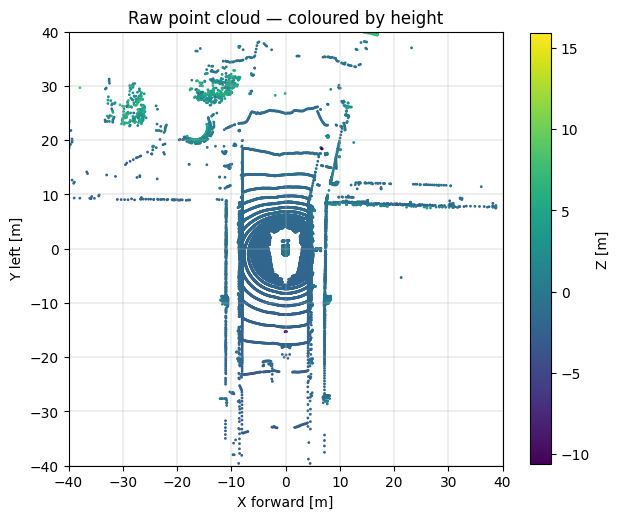

In [3]:
def bev_plot(points, title="BEV", lim=40, c=None, cmap="viridis",
             cbar_label=None, ax=None, s=1):
    """Top-down scatter of a point cloud. If `c` is None, colour by height."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 7))
    if c is None:
        c = points[:, 2]
    sc = ax.scatter(points[:, 0], points[:, 1], c=c, s=s, cmap=cmap)
    ax.set_xlabel("X forward [m]")
    ax.set_ylabel("Y left [m]")
    ax.set_title(title)
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_aspect("equal")
    ax.grid(True, lw=0.3)
    plt.colorbar(sc, ax=ax, label=cbar_label or "Z [m]", shrink=0.8)
    return ax


bev_plot(points, title="Raw point cloud — coloured by height")
plt.show()

## 3. Stage 1 — Ground filter (CZM + R-GPF, Patchwork++ style)

The **Concentric Zone Model** splits the ground around the sensor into concentric rings and then slices each ring into angular wedges. Rings further away use larger wedges (LiDAR points are sparser out there). Inside each wedge we run **R-GPF** (Regional Ground Plane Fitting):

1. **Seed selection.** Sort the wedge's points by height and take the lowest slice — e.g. `z` within `0.5 m` of the minimum. These are the best candidates for actual ground.
2. **Plane fit via PCA.** Compute the covariance of the seeds; the eigenvector for the smallest eigenvalue is the plane normal `n`.
3. **Sanity checks on the plane.** If the plane is nearly vertical (`|n_z|` tiny) it's a wall, not ground — reject. If the seed cloud is too thick (high σ in `z`) it's probably a bush or a steep slope — reject.
4. **Inlier labelling.** Every point in the wedge whose distance to the plane is below a threshold becomes a ground point.

> **Analogy.** Think of each wedge as a small patch of parking lot. You stand in it, squint at the ~20 lowest points, lay a ruler across them, and mark every other point within an inch of the ruler as "floor". Everything else = obstacle.

### The `k·σ` idea (paper Eq. 5)

Instead of using one fixed distance threshold everywhere, the paper normalises point-to-plane distance by the local seed σ in `z`:

$$D_i^{\mathrm{norm}} = \frac{|n \cdot p_i + d|}{\lVert n \rVert \, \sigma_z} \le k$$

This makes the threshold adapt automatically: a smooth asphalt patch gets a tight threshold, a gravelly one gets a looser one. We use this below together with a hard safety cap (`absolute_max_dist`) so the threshold never blows up on pathological wedges.

In [4]:
# -----------------------------------------------------------
# Concentric Zone Model — definition
# -----------------------------------------------------------
# Each row: (r_min, r_max, n_rings, n_sectors)
# Further zones get more sectors because they cover more arc length.
# Tweak these if your environment is very different.
CZM_ZONES = [
    # r_min  r_max  n_rings  n_sectors
    (   0.0,   4.0,       2,        16),
    (   4.0,  12.0,       3,        32),
    (  12.0,  25.0,       3,        54),
    (  25.0,  50.0,       2,        32),
]


def _pca_plane(pts):
    """Fit a plane through `pts` with PCA.

    Returns
    -------
    n        : (3,) unit normal, oriented so n_z >= 0
    c        : (3,) centroid
    eigvals  : (3,) eigenvalues, sorted descending (lam1 >= lam2 >= lam3)
    """
    c = pts.mean(axis=0)
    cov = np.cov((pts - c).T)
    w, V = np.linalg.eigh(cov)          # ascending eigenvalues
    eigvals = w[::-1]                   # descending
    n = V[:, 0]                         # eigenvector for smallest eigenvalue
    if n[2] < 0:                        # force normal to point up
        n = -n
    return n, c, eigvals


def czm_ground_filter(points,
                      zones=CZM_ZONES,
                      seed_band=0.5,          # [m] thickness of the lowest seed band
                      min_seeds=6,            # need this many seeds to fit a plane
                      max_seed_sigma_z=0.35,  # [m] reject "bush-like" noisy seeds
                      min_normal_z=0.8,       # reject near-vertical planes (walls)
                      k_sigma=3.0,            # Eq. 5 — normalised distance threshold
                      absolute_max_dist=0.4): # [m] hard cap on point-to-plane distance
    """Patchwork++-style ground filter using a CZM + R-GPF per sector.

    Returns a boolean mask of the same length as `points` (True = ground).
    """
    x, y, z = points[:, 0], points[:, 1], points[:, 2]
    r = np.sqrt(x * x + y * y)
    theta = np.arctan2(y, x)  # [-pi, pi]

    ground_mask = np.zeros(len(points), dtype=bool)

    for r0, r1, n_rings, n_sectors in zones:
        ring_edges = np.linspace(r0, r1, n_rings + 1)
        sec_edges = np.linspace(-np.pi, np.pi, n_sectors + 1)

        for ri in range(n_rings):
            in_ring = (r >= ring_edges[ri]) & (r < ring_edges[ri + 1])
            for si in range(n_sectors):
                in_sec = (theta >= sec_edges[si]) & (theta < sec_edges[si + 1])
                sector_idx = np.where(in_ring & in_sec)[0]
                if len(sector_idx) < min_seeds:
                    continue

                sec_pts = points[sector_idx]

                # --- 1. Seed selection: lowest band of points in this wedge
                z_min = sec_pts[:, 2].min()
                seed_mask = sec_pts[:, 2] < z_min + seed_band
                seeds = sec_pts[seed_mask]
                if len(seeds) < min_seeds:
                    continue

                # Reject wedges whose seeds are actually a bush/tree base (too spread in z)
                sigma_z = seeds[:, 2].std()
                if sigma_z > max_seed_sigma_z:
                    continue

                # --- 2. PCA plane through the seeds
                n, c, _ = _pca_plane(seeds)
                if n[2] < min_normal_z:          # plane too vertical -> wall
                    continue

                # --- 3. Label inliers in this wedge
                d_signed = (sec_pts - c) @ n      # signed distance to the plane
                d_abs = np.abs(d_signed)
                d_norm = d_abs / (sigma_z + 1e-6)   # paper Eq. 5
                inlier = (d_norm <= k_sigma) & (d_abs <= absolute_max_dist)
                ground_mask[sector_idx[inlier]] = True

    return ground_mask

Ground:   18,680 / 34,752  (53.8 %)


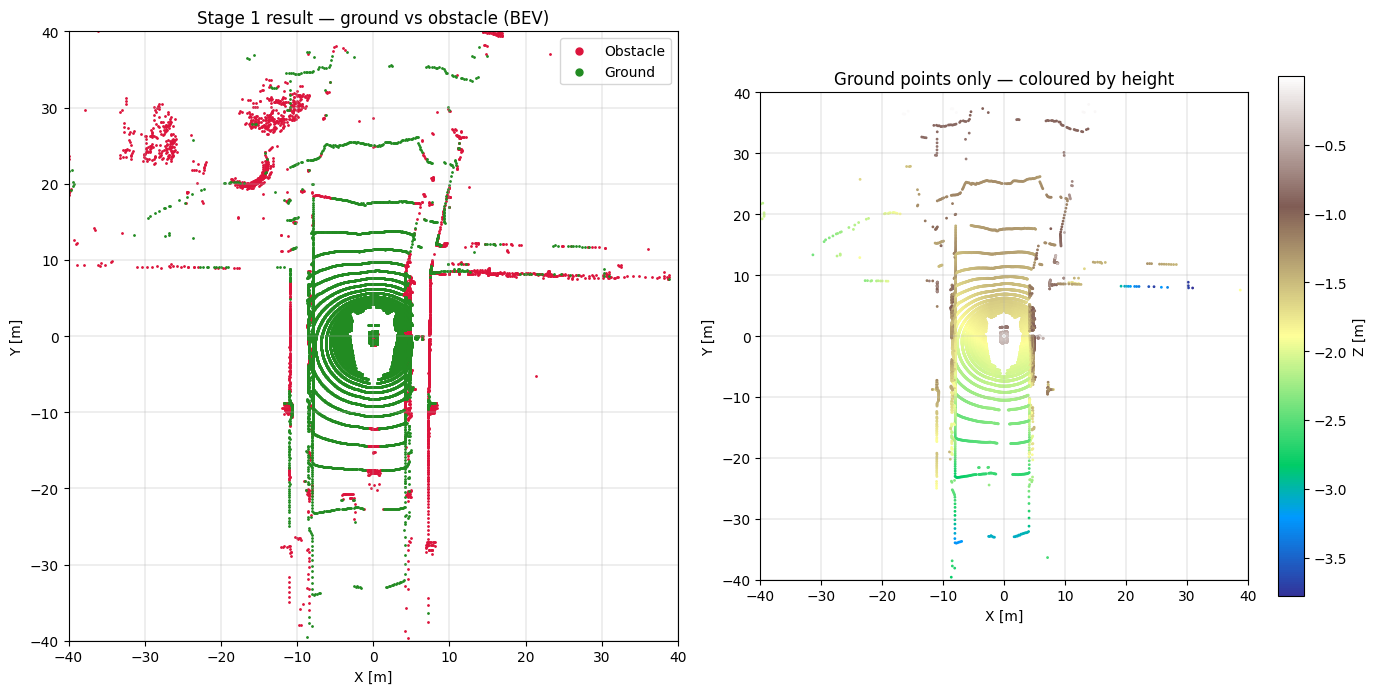

In [5]:
# Run the filter
ground_mask = czm_ground_filter(points)
n_ground = ground_mask.sum()
print(f"Ground:   {n_ground:,} / {len(points):,}  ({100 * n_ground / len(points):.1f} %)")

# Visualize ground vs obstacle
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

obstacles = points[~ground_mask]
ground = points[ground_mask]

axes[0].scatter(obstacles[:, 0], obstacles[:, 1], s=1, c="crimson", label="Obstacle")
axes[0].scatter(ground[:, 0],    ground[:, 1],    s=1, c="forestgreen", label="Ground")
axes[0].set_title("Stage 1 result — ground vs obstacle (BEV)")
axes[0].set_xlabel("X [m]"); axes[0].set_ylabel("Y [m]")
axes[0].set_xlim(-40, 40); axes[0].set_ylim(-40, 40)
axes[0].set_aspect("equal"); axes[0].grid(True, lw=0.3); axes[0].legend(markerscale=5)

# Ground only, coloured by height — should now look like terrain
sc = axes[1].scatter(ground[:, 0], ground[:, 1], c=ground[:, 2], s=1, cmap="terrain")
plt.colorbar(sc, ax=axes[1], label="Z [m]", shrink=0.8)
axes[1].set_title("Ground points only — coloured by height")
axes[1].set_xlabel("X [m]"); axes[1].set_ylabel("Y [m]")
axes[1].set_xlim(-40, 40); axes[1].set_ylim(-40, 40)
axes[1].set_aspect("equal"); axes[1].grid(True, lw=0.3)

plt.tight_layout(); plt.show()

## 4. Stage 2 — Slope and curvature per grid cell

Now we have clean ground points. Lay a uniform grid over them (simpler to read than a polar grid at this stage) and run PCA per cell. Two numbers come out of one PCA:

### Slope (from the normal vector)
PCA gives us the plane normal `n = (n_x, n_y, n_z)`. The angle it makes with the vertical `z`-axis is the slope:

$$\text{slope} = \arccos(n \cdot \hat z) \quad\text{(in degrees)}$$

### Curvature (from the eigenvalues)
Using paper Eq. (3):

$$\mathcal{C} = \frac{\lambda_3}{\lambda_1 + \lambda_2 + \lambda_3}$$

**Intuition.** $\lambda_1, \lambda_2, \lambda_3$ are the variances of the points along the three principal directions. $\lambda_3$ is the "thickness" of the fit (how much points deviate perpendicular to the plane). Divided by the total variance, it's a dimensionless measure of *how far from planar* the cell is.

- Flat asphalt: $\lambda_3 \approx 0 \Rightarrow \mathcal{C} \approx 0$
- Curved hill crest: $\lambda_3$ grows because points curve away from any single plane $\Rightarrow \mathcal{C}$ grows
- Speed bump inside a cell: $\mathcal{C}$ jumps

**Key distinction for the report.** Slope tells you the *orientation* of the best-fit plane; curvature tells you *how well a single plane fits at all*. A uniformly-tilted ramp has high slope but low curvature. A gently-rolling hill can have low slope but higher curvature.

Populated cells: 134
Slope     -- mean 15.00 deg  max 89.02 deg
Curvature -- mean 0.0118  max 0.1924


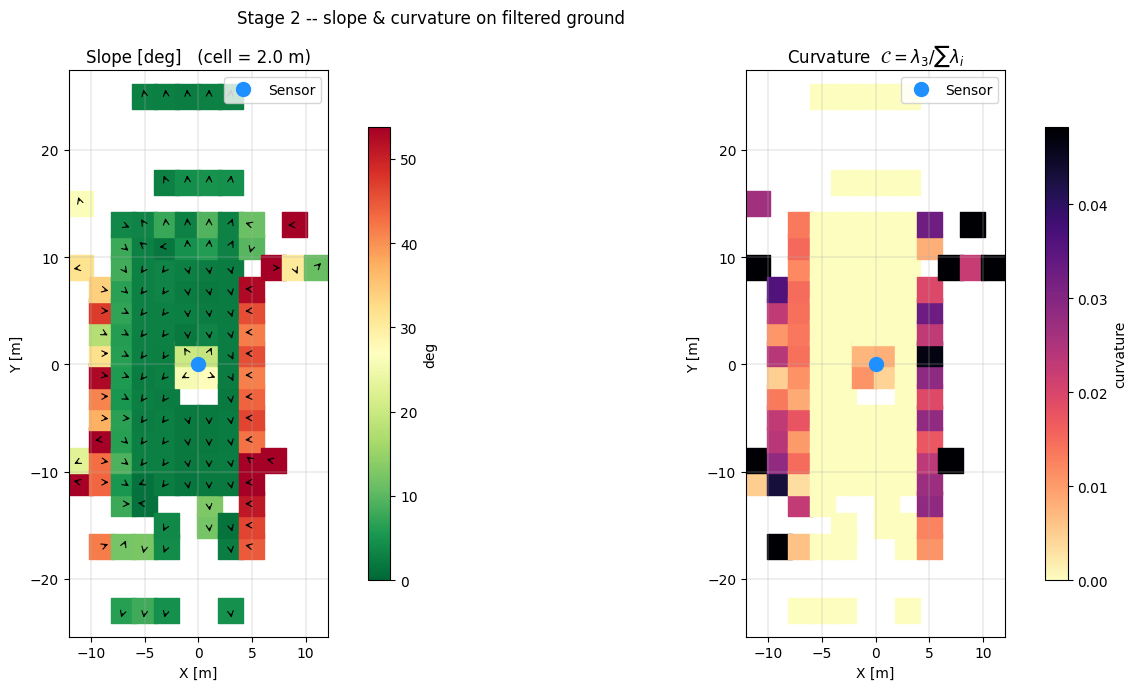

In [6]:
def compute_slope_curvature_grid(ground_points,
                                 cell_size=2.0,
                                 min_pts_per_cell=12,
                                 x_range=(-40, 40),
                                 y_range=(-40, 40)):
    """Uniform Cartesian grid over ground points. PCA per cell.

    Returns a dict with the following keys (one entry per populated cell):
        cx, cy  -- centre of the cell [m]
        slope   -- angle between PCA normal and +Z [deg]
        curv    -- lam3 / (lam1 + lam2 + lam3)   (paper Eq. 3)
        n_xy    -- (M, 2) tilt direction of the plane in BEV
    """
    x_edges = np.arange(x_range[0], x_range[1] + cell_size, cell_size)
    y_edges = np.arange(y_range[0], y_range[1] + cell_size, cell_size)

    ix = np.digitize(ground_points[:, 0], x_edges) - 1
    iy = np.digitize(ground_points[:, 1], y_edges) - 1
    valid = (ix >= 0) & (ix < len(x_edges) - 1) & (iy >= 0) & (iy < len(y_edges) - 1)
    ix, iy = ix[valid], iy[valid]
    pts = ground_points[valid]

    z_axis = np.array([0.0, 0.0, 1.0])
    cxs, cys, slopes, curvs, nxys = [], [], [], [], []

    # Bundle (ix, iy) into one integer key so we can group via np.unique — avoids a double loop
    lin = ix * len(y_edges) + iy
    for lin_key in np.unique(lin):
        cell_pts = pts[lin == lin_key]
        if len(cell_pts) < min_pts_per_cell:
            continue
        n, _, eigvals = _pca_plane(cell_pts)
        slope_deg = np.degrees(np.arccos(np.clip(n @ z_axis, -1.0, 1.0)))
        curvature = eigvals[2] / (eigvals.sum() + 1e-12)

        i_cell = lin_key // len(y_edges)
        j_cell = lin_key %  len(y_edges)
        cxs.append(0.5 * (x_edges[i_cell] + x_edges[i_cell + 1]))
        cys.append(0.5 * (y_edges[j_cell] + y_edges[j_cell + 1]))
        slopes.append(slope_deg)
        curvs.append(curvature)
        nxys.append(n[:2])

    return dict(
        cx=np.array(cxs), cy=np.array(cys),
        slope=np.array(slopes), curv=np.array(curvs),
        n_xy=np.array(nxys) if nxys else np.zeros((0, 2)),
    )


def plot_slope_curvature(g, cell_size, suptitle=""):
    """Side-by-side slope and curvature heatmaps. Arrows show tilt direction per cell."""
    if len(g["cx"]) == 0:
        print("No populated cells.")
        return

    fig, axes = plt.subplots(1, 2, figsize=(15, 7))

    # --- slope ---
    vmax = float(np.percentile(g["slope"], 95))
    sc = axes[0].scatter(g["cx"], g["cy"], c=g["slope"], cmap="RdYlGn_r",
                         s=(cell_size * 9) ** 2, marker="s", vmin=0, vmax=vmax)
    for i in range(len(g["cx"])):
        d = g["n_xy"][i]
        m = np.linalg.norm(d)
        if m > 1e-3:
            d = d / m * cell_size * 0.45
            axes[0].annotate(
                "", xy=(g["cx"][i] + d[0], g["cy"][i] + d[1]),
                xytext=(g["cx"][i], g["cy"][i]),
                arrowprops=dict(arrowstyle="->", color="black", lw=0.8),
            )
    axes[0].plot(0, 0, "o", color="dodgerblue", ms=10, label="Sensor")
    axes[0].set_title(f"Slope [deg]   (cell = {cell_size} m)")
    plt.colorbar(sc, ax=axes[0], label="deg", shrink=0.8)

    # --- curvature ---
    vmax_c = float(np.percentile(g["curv"], 95))
    sc2 = axes[1].scatter(g["cx"], g["cy"], c=g["curv"], cmap="magma_r",
                          s=(cell_size * 9) ** 2, marker="s", vmin=0, vmax=vmax_c)
    axes[1].plot(0, 0, "o", color="dodgerblue", ms=10, label="Sensor")
    axes[1].set_title(r"Curvature  $\mathcal{C} = \lambda_3 / \sum\lambda_i$")
    plt.colorbar(sc2, ax=axes[1], label="curvature", shrink=0.8)

    for ax in axes:
        ax.set_xlabel("X [m]"); ax.set_ylabel("Y [m]")
        ax.set_aspect("equal"); ax.grid(True, lw=0.3)
        ax.legend(loc="upper right")
    if suptitle:
        fig.suptitle(suptitle)
    plt.tight_layout()
    plt.show()


CELL = 2.0
grid = compute_slope_curvature_grid(points[ground_mask], cell_size=CELL)

print(f"Populated cells: {len(grid['cx'])}")
print(f"Slope     -- mean {grid['slope'].mean():5.2f} deg  max {grid['slope'].max():5.2f} deg")
print(f"Curvature -- mean {grid['curv'].mean():.4f}  max {grid['curv'].max():.4f}")

plot_slope_curvature(grid, CELL, suptitle="Stage 2 -- slope & curvature on filtered ground")

## 5. Stage 3 — A whole drive: trajectory + per-frame slope/curvature

Point this at a **folder of `.bin` files** and it will:

1. Run Stages 1–2 on every frame.
2. At each frame, record the slope and curvature of the cells right underneath the sensor (within a small radius around `(0,0)` in the local frame) — that's what the IMU would feel.
3. Optionally transform per-frame sensor positions into a global frame if you give it a poses file.
4. Save a CSV with `[frame, timestamp, x, y, z, slope, curvature]` for direct comparison against your IMU log.

**About poses.** If you have them, provide a CSV with columns `timestamp, x, y, z` (3-D trajectory) or `timestamp, x, y, z, qw, qx, qy, qz` (full pose) — rows in the same order as the sorted `.bin` files. If you don't, the function falls back to using the frame index as the x-axis, which still gives you a time series of slope/curvature that you can cross-correlate with an IMU stream by timestamp.

In [7]:
def process_sequence(bin_folder,
                     poses_csv=None,
                     cell_size=2.0,
                     ego_radius=3.0,
                     verbose=True):
    """Run Stages 1-2 on every .bin in a folder and log sensor-local slope/curvature.

    Parameters
    ----------
    bin_folder : str
        Folder containing .bin files. Processed in sorted filename order.
    poses_csv  : str or None
        Optional CSV with at least columns [timestamp, x, y, z]. Rows must match
        the sorted .bin files one-for-one. If None, frame index is used.
    cell_size  : float
        Same as Stage 2.
    ego_radius : float
        Radius [m] around (0, 0) in the local frame used to pick the cells that
        represent "what the vehicle is driving over right now".

    Returns
    -------
    dict of np.ndarray keyed by: frame, timestamp, x, y, z, slope, curv
    """
    bin_files = sorted(glob.glob(os.path.join(bin_folder, "*.bin")))
    if not bin_files:
        raise FileNotFoundError(f"No .bin files in {bin_folder}")

    poses = None
    if poses_csv is not None:
        poses = np.genfromtxt(poses_csv, delimiter=",", names=True)
        if len(poses) != len(bin_files):
            print(f"[warn] {len(poses)} poses vs {len(bin_files)} bins -- "
                  "truncating to the shorter one.")
        L = min(len(poses), len(bin_files))
        bin_files = bin_files[:L]

    out = {k: [] for k in ("frame", "timestamp", "x", "y", "z", "slope", "curv")}

    for fi, bf in enumerate(bin_files):
        pc = load_nuscenes_bin(bf)
        mask = czm_ground_filter(pc)
        grid = compute_slope_curvature_grid(pc[mask], cell_size=cell_size)

        # Average slope/curv of cells within ego_radius of the sensor
        if len(grid["cx"]) == 0:
            slope_here = curv_here = np.nan
        else:
            r = np.sqrt(grid["cx"] ** 2 + grid["cy"] ** 2)
            near = r <= ego_radius
            if near.any():
                slope_here = float(np.nanmean(grid["slope"][near]))
                curv_here  = float(np.nanmean(grid["curv"][near]))
            else:
                slope_here = curv_here = np.nan

        if poses is not None:
            out["timestamp"].append(float(poses["timestamp"][fi]))
            out["x"].append(float(poses["x"][fi]))
            out["y"].append(float(poses["y"][fi]))
            out["z"].append(float(poses["z"][fi]))
        else:
            out["timestamp"].append(float(fi))
            out["x"].append(float(fi))   # placeholder: frame index on x-axis
            out["y"].append(0.0)
            out["z"].append(0.0)

        out["frame"].append(fi)
        out["slope"].append(slope_here)
        out["curv"].append(curv_here)

        if verbose and fi % 10 == 0:
            print(f"[{fi + 1}/{len(bin_files)}] {os.path.basename(bf)}  "
                  f"slope={slope_here:.2f} deg  curv={curv_here:.4f}")

    return {k: np.array(v) for k, v in out.items()}


# -------- usage example --------
# Point this at a folder containing a sequence of .bin files.
SEQ_FOLDER = r"C:/Users/JRepa/OneDrive - Delft University of Technology/Documenten/02. TU Delft/2025-2026/BEP/Data/Pointclouds curvature/sequence"
POSES_CSV  = None   # or path to "poses.csv" with header: timestamp,x,y,z

# Uncomment to run on a full sequence:
# traj = process_sequence(SEQ_FOLDER, poses_csv=POSES_CSV)
# print("Done. Frames processed:", len(traj['frame']))

In [8]:
def plot_trajectory(traj):
    """Two plots:
      (a) trajectory in XY coloured by slope
      (b) slope & curvature vs frame/time
    """
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    valid = ~np.isnan(traj["slope"])
    if valid.any():
        sc = axes[0].scatter(traj["x"][valid], traj["y"][valid],
                             c=traj["slope"][valid], cmap="RdYlGn_r",
                             s=20, vmin=0,
                             vmax=np.nanpercentile(traj["slope"], 95))
        plt.colorbar(sc, ax=axes[0], label="Slope [deg]", shrink=0.8)
    axes[0].plot(traj["x"], traj["y"], "-", color="gray", lw=0.6, zorder=0)
    axes[0].set_xlabel("X [m]"); axes[0].set_ylabel("Y [m]")
    axes[0].set_title("Trajectory coloured by local slope")
    axes[0].set_aspect("equal"); axes[0].grid(True, lw=0.3)

    # time series -- slope and curvature on a twin y-axis
    ax2 = axes[1]
    ax2.plot(traj["frame"], traj["slope"], color="tab:blue", label="slope [deg]")
    ax2.set_xlabel("Frame"); ax2.set_ylabel("Slope [deg]", color="tab:blue")
    ax2.tick_params(axis="y", labelcolor="tab:blue")
    ax2b = ax2.twinx()
    ax2b.plot(traj["frame"], traj["curv"], color="tab:red", label="curvature")
    ax2b.set_ylabel("Curvature", color="tab:red")
    ax2b.tick_params(axis="y", labelcolor="tab:red")
    ax2.set_title("Per-frame slope & curvature")
    ax2.grid(True, lw=0.3)

    plt.tight_layout()
    plt.show()


def save_trajectory_csv(traj, path="lidar_slope_curvature.csv"):
    """Write per-frame result as CSV -- ready to merge with an IMU log by timestamp."""
    header = "frame,timestamp,x,y,z,slope_deg,curvature"
    stacked = np.column_stack([traj["frame"], traj["timestamp"],
                               traj["x"], traj["y"], traj["z"],
                               traj["slope"], traj["curv"]])
    np.savetxt(path, stacked, delimiter=",", header=header, comments="",
               fmt=["%d", "%.6f", "%.3f", "%.3f", "%.3f", "%.3f", "%.6f"])
    print(f"Saved: {path}")


# -------- usage example --------
# plot_trajectory(traj)
# save_trajectory_csv(traj, "lidar_slope_curvature.csv")

## Notes you can lift into the BEP report

**Design decisions (and *why*):**

| Choice | Alternative considered | Reason for the chosen option |
|--------|-----------------------|------------------------------|
| CZM for Stage 1 | Uniform polar grid; Cartesian grid | Matches the radial sparsity of LiDAR — close rings have many points, far rings have few, so wedges grow with range. |
| PCA for local planes | RANSAC | Deterministic, uses every point, closed-form. After Stage 1 the sector is already mostly ground, so consensus-from-samples buys nothing. |
| `k·σ` normalised distance (Eq. 5) | Fixed distance threshold | Tightens automatically on smooth patches, relaxes on rough ones — no global tuning. |
| Uniform Cartesian grid for Stage 2 | Reuse CZM | Easier to read in plots and to cross-reference with the vehicle's path; obstacle removal is already done upstream. |
| $\lambda_3/\sum\lambda_i$ as curvature (Eq. 3) | Mean curvature from a quadric fit | Cheap, dimensionless, co-computed with the normal in the same PCA step. |

**Validation experiments worth running:**

- **Scale sweep.** Vary `cell_size` over `{1, 2, 3, 5} m` and plot how the distribution of slope/curvature changes. Shows the spatial-scale trade-off that any terrain estimator has to defend.
- **IMU cross-check.** Compute the cross-correlation of `slope(t)` (from this pipeline) against IMU pitch, and similarly for IMU roll vs the tilt-direction angle. Report the lag of the peak correlation (a good pipeline has lag ≈ 0) and the RMSE in the overlapping band.
- **Flat-ground baseline.** Run the whole pipeline on a scene you already know is flat (empty parking lot). Slope and curvature should be near zero everywhere — if they aren't, you've found a noise floor to report.
- **Sensitivity to `k_sigma`.** Sweep `k_sigma` in `czm_ground_filter` and measure ground-point fraction and slope-field stability. Same shape of study as Tables 2 and 4 in the paper, just on your data.

**What's *not* in this pipeline (and why that's fine):** the TE-NeXt sparse neural network from Santo et al. is deliberately skipped. Its role in the paper is to rescue sparse far-range sectors where geometric methods run out of points. For your IMU-comparison work the vehicle only "feels" the terrain under and immediately around it — the sparse far range doesn't enter the measurement — so the geometric core is sufficient and keeps the method interpretable for your defence.